In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Read data
data = pd.read_csv("pokemonDB_dataset.csv", delimiter=',')


In [3]:
# Clean data and convert to numeric format
data['Height'] = data['Height'].str.extract(r'(\d+\.\d+)').astype(float)
data['Weight'] = data['Weight'].str.extract(r'(\d+\.\d+)').astype(float)
data['HP Base'] = data['HP Base'].astype(float)

# Sort by the 'Height' column
data.sort_values(by=['Height', 'Weight'], inplace=True)

# Original data for comparison
original_data = data.copy()


In [4]:
# Recalculate the mean and standard deviation for the full dataset
mean_weight = data['Weight'].mean()
std_weight = data['Weight'].std()

# Set the anomaly threshold to mean + 5 standard deviations
weight_threshold = mean_weight + 5 * std_weight

# Apply this threshold to filter the data
simple_filtered_data = data[(data['Weight'] <= weight_threshold) & (data['Weight'] != '—')]

# Review results after applying the simplified filtering method
print(simple_filtered_data[['Pokemon', 'Height', 'Weight']].head())
print(original_data[['Pokemon', 'Height', 'Weight']].head())


                     Pokemon  Height  Weight
338                  Flabébé     0.1     0.1
385  Gimmighoul Roaming Form     0.1     0.1
214                 Cutiefly     0.1     0.2
945                 Sinistea     0.1     0.2
186                   Comfey     0.1     0.3
                     Pokemon  Height  Weight
338                  Flabébé     0.1     0.1
385  Gimmighoul Roaming Form     0.1     0.1
214                 Cutiefly     0.1     0.2
945                 Sinistea     0.1     0.2
186                   Comfey     0.1     0.3


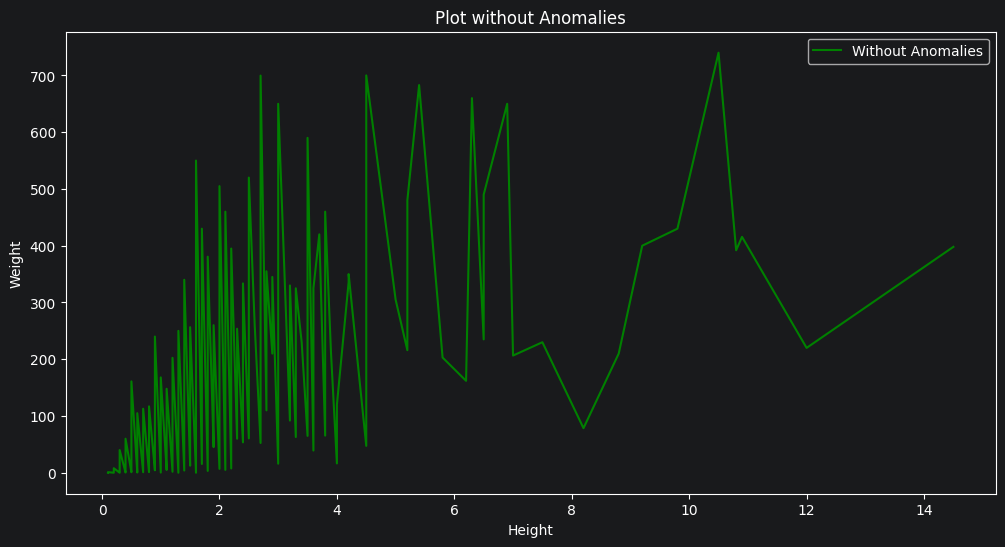

In [5]:
# Visualization
plt.figure(figsize=(12, 6))

# Plot without Anomalies
plt.plot(simple_filtered_data['Height'], simple_filtered_data['Weight'], 'g', label='Without Anomalies')
plt.title('Plot without Anomalies')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.show()


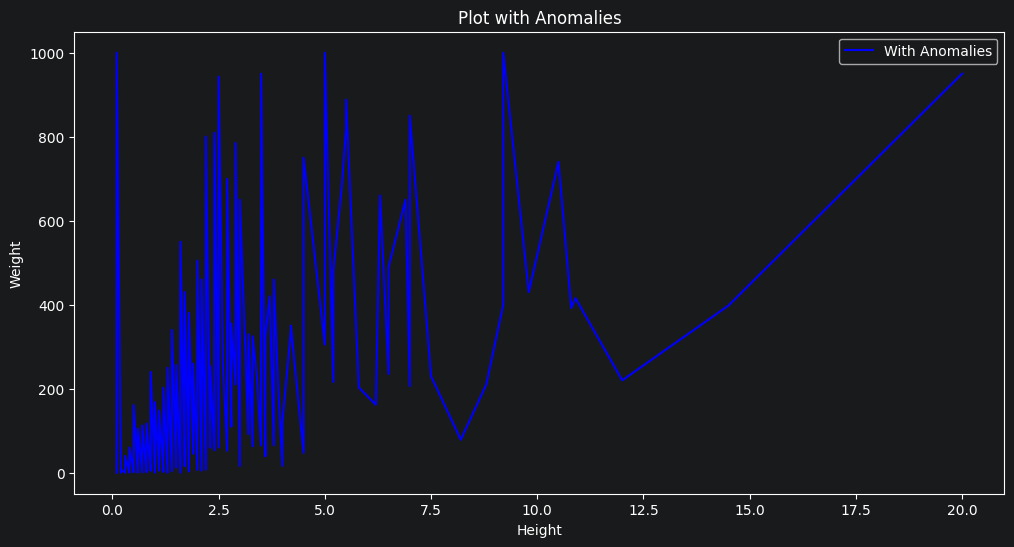

In [6]:
# Visualization
plt.figure(figsize=(12, 6))


# Plot with Anomalies
plt.plot(original_data['Height'], original_data['Weight'], 'b', label='With Anomalies')
plt.title('Plot with Anomalies')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()
plt.show()
